In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import torch.optim as optim
import matplotlib.pyplot as plt
import os
from torch.optim.optimizer import Optimizer, required
## two layer neural network
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import numpy as np
import matplotlib.pyplot as plt

In [3]:
##

def swish(x):
  return x * F.sigmoid(x)

def snake(x):
  return x + torch.sin(x)**2


class Linear(nn.Module):

    def __init__(self, in_dim, out, bias=False):
        super(Linear, self).__init__()

        #w = torch.zeros(d).normal_()
        self.w = nn.Linear(in_dim, out, bias=False)


    def forward(self, x):
        self.ha = x
        if x.requires_grad:
          self.ha.retain_grad()


        x = self.w(x)
        self.hb = x
        #if x.requires_grad:
        self.hb.retain_grad()
        return x

    def backproj_nobias(self,y):
        # assume no bias

        self.hb.grad=y
        #self.hb.retain_grad()

        x = torch.mm(y,self.w.weight)

        self.ha.grad=x
        #self.ha.retain_grad()

        return x


def mask_processing(x,mask_mode,x_masks):
      if mask_mode==1:
        x_masks.append((F_relu(x)!=0).detach())
      elif mask_mode==2:
        x = x*(x_masks[0].detach())
        x_masks.pop(0)
      return x

# class BiLinear(nn.Module):
#     def __init__(self,in_d,out_d,bias=False):
#         super(Net, self).__init__()
#         self.linear = Linear(in_d,out_d,bias=bias)

#     def forward(self, x):
#         x = self.linear(x)
#         return x

#     def backproj(self,x):
#         pass


class Net(nn.Module):

    def __init__(self, width=10, depth=1,in_d=5,out_d=5, F=F.relu):
        super(Net, self).__init__()

        #w = torch.zeros(d).normal_()
        self.w = Linear(in_d, 200, bias=False)

        self.w2 = Linear(200, 100, bias=False)

        self.w3 = Linear(100, 200, bias=False)
        #self.w.weight.data.normal_(0, 0.5 * d ** -0.5)
        self.u = Linear(200, out_d, bias=False)
        #self.u.weight.data.normal_(0, 0.5 * 1)
        self.h = 0
        self.F = F

    def backproj(self,x,x_masks=None,nonlin=None):
        if x_masks:
          x_masks = list(reversed(x_masks.copy()))
          mask_mode = 2

        x = self.u.backproj_nobias(x)
        if nonlin:
          x = nonlin(x)
        if x_masks:
          x = mask_processing(x,mask_mode,x_masks)

        x = self.w3.backproj_nobias(x)
        if nonlin:
          x = nonlin(x)
        if x_masks:
          x = mask_processing(x,mask_mode,x_masks)

        x = self.w2.backproj_nobias(x)
        if nonlin:
          x = nonlin(x)
        if x_masks:
          x = mask_processing(x,mask_mode,x_masks)

        x = self.w.backproj_nobias(x)

        return x


    def forward(self, x, x_masks=None, nonlin=None):

        if isinstance(x_masks, list):
          if len(x_masks) == 0:
            # if received empty list, fill the list with masks
            mask_mode=1
          else:
            # if received list with elements, use the masks
            # make a clone of it to not modify it
            x_masks=x_masks.copy()
            mask_mode=2
        else:
          # if not received any list, do not use it
          mask_mode=0


        if nonlin:
          used_nonlin = nonlin
        else:
          used_nonlin = self.F

        x = x.view(x.shape[0], -1)

        x = self.w(x)
        x = mask_processing(x,mask_mode,x_masks)
        x = used_nonlin(x)

        x = self.w2(x)
        x = mask_processing(x,mask_mode,x_masks)

        x = used_nonlin(x)
        x = self.w3(x)
        x = mask_processing(x,mask_mode,x_masks)

        x = used_nonlin(x)

        x = self.u(x)


        return x


model = Net()

def F_relu(x):
    return F.relu(x)

def F_identity(x):
    return x


In [21]:
#model.w.w.weight.shape


In [4]:
def update_grad_old_autograd(Net1, Net2, X, Y):

          x_masks=[]
          output = Net1(X,x_masks=x_masks)
          output.retain_grad()
          loss = loss_fn(output, Y)
          loss.backward()

          # print(len(x_masks))
          O = output.grad.detach()
          #print(O.shape)
          O2 = Net2(X,x_masks=x_masks)
          loss2 = torch.trace(O.mm(O2.T))
          loss2.backward()
          loss_2_true = loss_fn(O2, Y)
          for t, s in zip(Net1.modules(), Net2.modules()):
            #print(t, s)
            if isinstance(t, Linear):
              #print(1)
              h = t.ha
              gh = s.hb.grad
              #print(h, gh)

              grad = gh.T.mm(h)

              t.w.weight.grad = grad
              #t.w.grad += grad
              s.w.weight.grad = grad

          return loss.item(), loss_2_true.item()


def update_grad(Net1, Net2, X, Y):

          x_masks=[]
          output = Net1(X,x_masks=x_masks)
          output.retain_grad()
          loss = loss_fn(output, Y)
          loss.backward()

          # print(len(x_masks))
          O = output.grad.detach()
          #print(O.shape)
          O2 = Net2(X,x_masks=x_masks)
          loss2 = torch.trace(O.mm(O2.T))
          # loss2.backward()
          loss_2_true = loss_fn(O2, Y)

          In2_backproj = Net2.backproj(O,x_masks=x_masks,nonlin=None)

          for t, s in zip(Net1.modules(), Net2.modules()):
            #print(t, s)
            if isinstance(t, Linear):
              #print(1)
              h = t.ha
              gh = s.hb.grad
              #print(h, gh)

              grad = gh.T.mm(h)

              t.w.weight.grad = grad
              #t.w.grad += grad
              s.w.weight.grad = grad

          return loss.item(), loss_2_true.item()

def mse(Z,Y):
  return ((Z - Y) **2).sum(-1).mean()

In [5]:

noise_range = [0.01]#np.arange(0.1, 5, 0.8)
matrices = []

d = 64

losses = []

loss_fn = mse

for noise in noise_range:

    for lr in [0.005]:
        torch.manual_seed(10)
        print(noise, lr)

        model1 = Net(width=d, depth=1, in_d=d,out_d=d).cuda()
        model2 = Net(width=d, depth=1, in_d=d,out_d=d,F=F_identity).cuda()

        #opt = optim.Adam(model1.parameters(), lr=1e-3, weight_decay=1e-)
        #opt = optim.Adam(model2.parameters(), lr=1e-3, weight_decay=1e-3)
        opt1 = optim.SGD(model1.parameters(), lr=0.1e-1, weight_decay=0.15e-1)#.3e-1)
        opt2 = optim.SGD(model2.parameters(), lr=0.1e-1, weight_decay=0.15e-1)#.3e-1)

        STEP = 10000
        #criterion = F.mse_loss
        #sum_loss = 0

        W = torch.zeros(d, d).cuda().normal_()
        W[d//2:] *= 0

        for i in range(STEP):


          N = 100
          X = torch.zeros([N, d]).normal_(0,1).cuda()#* torch.Tensor(np.arange(0.01, 2.01, 2 / d)).cuda()

          eps = noise * torch.zeros([N, d]).normal_(0,1).cuda()#* torch.Tensor(np.arange(0.01, 2.01, 2 / d)).cuda()
          #eps[2:] = 0


          Y =  X + eps.mm(W) #* mask #.mean(dim=1, keepdim=True) #+ eps
          #print(X.shape, Y.shape)

          opt1.zero_grad()
          opt2.zero_grad()




          #print(output.shape, Y.shape)
          loss, loss_2_true = update_grad(model1, model2, X, Y)


          if False:
            loss = ((output - Y) **2).sum(-1).mean()
            loss.backward()

            O = output.grad.detach()
            #print(O.shape)
            O2 = model2(X)
            loss2 = torch.trace(O.mm(O2.T))
            loss2.backward()
            for t, s in zip(model1.modules(), model2.modules()):
              #print(t, s)
              if isinstance(t, Linear):
                #print(1)
                h = t.ha
                gh = s.hb.grad
                #print(h, gh)

                grad = gh.T.mm(h)

                t.w.weight.grad = grad
                #t.w.grad += grad
                s.w.weight.grad = grad
          torch.nn.utils.clip_grad_norm_(model2.parameters(), 10)
          torch.nn.utils.clip_grad_norm_(model1.parameters(), 10)


          #for t, s in zip(model1.modules(), model2.modules()):
            #print(t, s)
          #    if isinstance(t, Linear):
           #     print(t.w.weight.grad.norm())
          #      print(s.w.weight.grad.norm())
              #t.w.grad += grad
              #s.w.weight.grad = grad

          #print(loss.item())

          #print(O2.shape, O.shape)
          losses.append([loss, loss_2_true])

          if i % 30 ==0:
            print(loss, loss_2_true)

          opt1.step()
          opt2.step()
            #with torch.no_grad():


0.01 0.005
65.35823822021484 65.2677230834961
63.26798629760742 63.38949203491211
63.3557014465332 63.86199188232422
64.40113830566406 65.77484893798828
61.24508285522461 64.0810317993164
60.040916442871094 64.56754302978516
53.29528045654297 60.453125
50.95079040527344 61.095985412597656
48.795188903808594 59.86907196044922
45.70941162109375 60.2906379699707
41.69546890258789 57.05788040161133
42.26881790161133 61.32246017456055
37.664371490478516 56.47264862060547
38.721256256103516 60.67695236206055
37.85686111450195 63.49694061279297
36.3918571472168 62.2574348449707
35.98814392089844 63.58611297607422
34.23857498168945 61.95050048828125
33.99793243408203 64.67399597167969
33.17974090576172 65.53990173339844
32.16323471069336 66.91242980957031
30.427690505981445 66.2609634399414
29.918622970581055 67.41873931884766
29.49343490600586 65.21581268310547
30.274959564208984 68.86261749267578
28.915199279785156 67.11014556884766
27.877870559692383 65.85624694824219
26.21603012084961 67.0

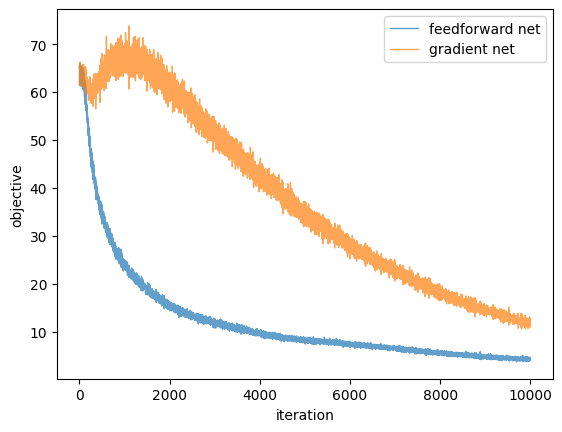

In [6]:
losses = np.array(losses)
plt.plot(losses[:,0], alpha=0.7, lw=1, label='feedforward net')
plt.plot(losses[:,1], alpha=0.7, lw=1, label='gradient net')
plt.ylabel('objective')
plt.xlabel('iteration')
plt.legend()
#plt.loglog()

In [ ]:
### mnist

In [7]:
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:00<00:00, 52545803.79it/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 2246706.86it/s]

Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 18646845.94it/s]

Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw



Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 8190253.12it/s]

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



In [8]:
batch_size = 256

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([256, 1, 28, 28])
Shape of y: torch.Size([256]) torch.int64


In [9]:
#loss_fn = nn.MSELoss()
device = 'cuda'
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

def converter(indices):
    '''
    convert indices to one-hot encoding
    '''
    probvec = torch.zeros(len(indices), 10)
    for number, index in enumerate(indices):
      probvec[number][index] = 1.0
    return probvec

def train(dataloader, model1, model2, loss_fn, opt1, opt2):
    global losses
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        y = converter(y)
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        #pred = model(X)
        #loss = loss_fn(pred, y)
        opt1.zero_grad()
        opt2.zero_grad()
        loss, loss2 = update_grad(model1, model2, X, y)

        # Backpropagation

        opt1.step()
        opt2.step()

        if batch % 50 == 0:
            #loss, current = loss.item(), batch * len(X)
            print(loss, loss2)
        losses.append([loss, loss2])

def test(dataloader, model, loss_fn,nonlin=None):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    #model.eval()
    test_loss, correct = 0, 0
    #with torch.no_grad():
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X,nonlin=nonlin)
        #test_loss += loss_fn(pred, converter(y)).item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [10]:
epochs = 10
## model1 is the feedforward, model2 is the gradient net

model1 = Net(in_d=784,out_d=10).cuda()
model2 = Net(in_d=784,out_d=10,F=F_identity).cuda()
opt1 = optim.SGD(model1.parameters(), lr=0.5e-1, weight_decay=0.001, momentum=0.9)#.3e-1)
opt2 = optim.SGD(model2.parameters(), lr=0.5e-1, weight_decay=0.001, momentum=0.9)#.3e-1)

losses =[]

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model1, model2, loss_fn, opt1, opt2)
    test(test_dataloader, model1, loss_fn)
    test(test_dataloader, model2, loss_fn, nonlin=F_relu)

print("Done!")

Epoch 1
-------------------------------
2.3022477626800537 2.300825357437134
2.1893062591552734 2.10506010055542
0.6592712998390198 0.7880206108093262
0.4487517178058624 0.47122400999069214
0.32531511783599854 0.3688375949859619
Test Error: 
 Accuracy: 91.1%, Avg loss: 0.000000 

Test Error: 
 Accuracy: 89.4%, Avg loss: 0.000000 

Epoch 2
-------------------------------
0.306020587682724 0.385763943195343
0.30389106273651123 0.32773682475090027
0.2441735565662384 0.2718214988708496
0.16623368859291077 0.19625602662563324
0.1468653380870819 0.16283506155014038
Test Error: 
 Accuracy: 94.6%, Avg loss: 0.000000 

Test Error: 
 Accuracy: 94.0%, Avg loss: 0.000000 

Epoch 3
-------------------------------
0.16014991700649261 0.17401349544525146
0.1840260922908783 0.2070450633764267
0.22735652327537537 0.27119356393814087
0.13165028393268585 0.15475572645664215
0.124697245657444 0.13638906180858612
Test Error: 
 Accuracy: 95.8%, Avg loss: 0.000000 

Test Error: 
 Accuracy: 95.0%, Avg loss: 0

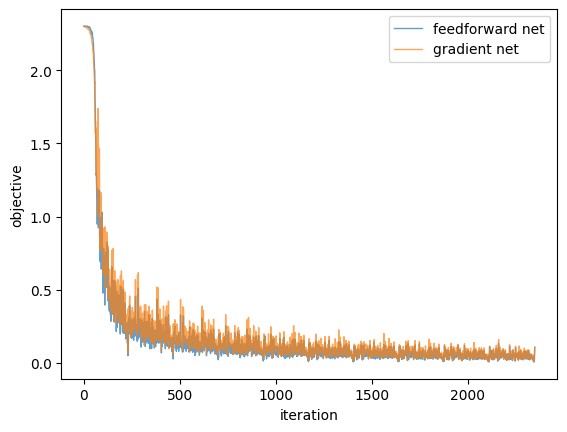

In [11]:
losses = np.array(losses)
plt.plot(losses[:,0], alpha=0.7, lw=1, label='feedforward net')
plt.plot(losses[:,1], alpha=0.7, lw=1, label='gradient net')
plt.ylabel('objective')
plt.xlabel('iteration')
plt.legend()
#plt.loglog()

In [ ]:
losses

[[2.3030683994293213, 2.3046555519104004],
 [tensor(2.3024, device='cuda:0', grad_fn=<DivBackward1>), 2.3032846450805664],
 [tensor(2.3031, device='cuda:0', grad_fn=<DivBackward1>), 2.3026466369628906],
 [tensor(2.3045, device='cuda:0', grad_fn=<DivBackward1>), 2.301334857940674],
 [tensor(2.3027, device='cuda:0', grad_fn=<DivBackward1>), 2.3014817237854004],
 [tensor(2.3039, device='cuda:0', grad_fn=<DivBackward1>), 2.302187442779541],
 [tensor(2.3018, device='cuda:0', grad_fn=<DivBackward1>), 2.3026490211486816],
 [tensor(2.3030, device='cuda:0', grad_fn=<DivBackward1>), 2.3005309104919434],
 [tensor(2.3041, device='cuda:0', grad_fn=<DivBackward1>), 2.299417495727539],
 [tensor(2.3028, device='cuda:0', grad_fn=<DivBackward1>), 2.2986912727355957],
 [tensor(2.3020, device='cuda:0', grad_fn=<DivBackward1>), 2.29823637008667],
 [tensor(2.3022, device='cuda:0', grad_fn=<DivBackward1>), 2.297652244567871],
 [tensor(2.3021, device='cuda:0', grad_fn=<DivBackward1>), 2.2968616485595703],
 [t